Decision Tree for Banknote Authentication Dataset
1. Image Feature Analysis
Variance: Measures the spread of pixel values.
Skewness: Indicates asymmetry in the pixel distribution.
Kurtosis: Reflects the 'tailedness' of the pixel distribution.
Entropy: Quantifies the complexity or randomness in the image.

2. Data Loading and Visualization

Dataset shape: (1372, 4)

First 5 samples:


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


<Figure size 1000x800 with 0 Axes>

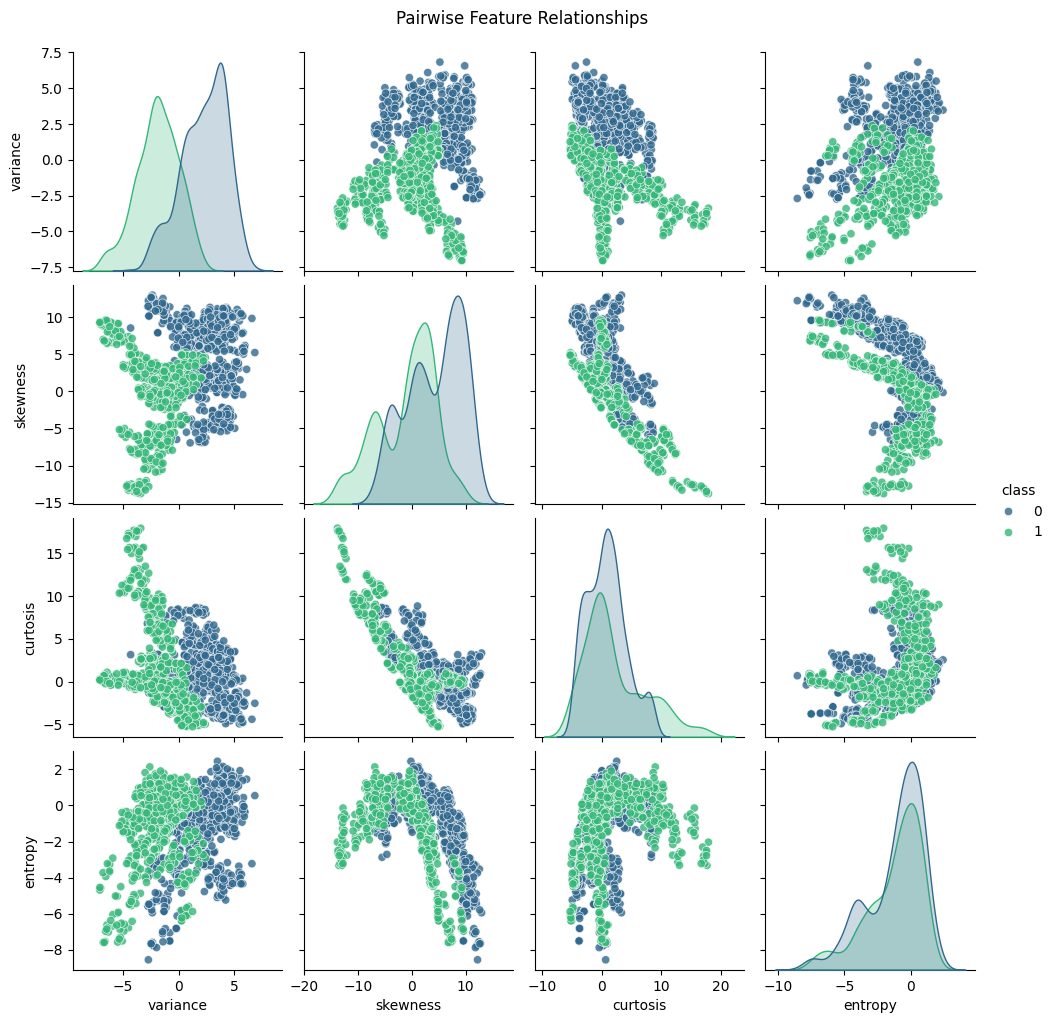

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
banknote_authentication = fetch_ucirepo(id=267) 
  
# data (as pandas dataframes) 
X = banknote_authentication.data.features 
y = banknote_authentication.data.targets 
  
# Show dataset info
print("Dataset shape:", X.shape)
print("\nFirst 5 samples:")
display(pd.concat([X.head(), y.head()], axis=1))

# Combined DataFrame
df = pd.concat([X, y], axis=1)

plt.figure(figsize=(10, 8))
sns.pairplot(df, hue='class', palette='viridis', plot_kws={'alpha':0.8})
plt.suptitle('Pairwise Feature Relationships', y=1.02)
plt.show()

Comment: The pairwise plots show clear separations between classes, suggesting decision trees could perform well.

3. Model Training and Evaluation

Training samples: 1097
Test samples: 275
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.94       153
           1       0.88      1.00      0.94       122

    accuracy                           0.94       275
   macro avg       0.94      0.95      0.94       275
weighted avg       0.95      0.94      0.94       275



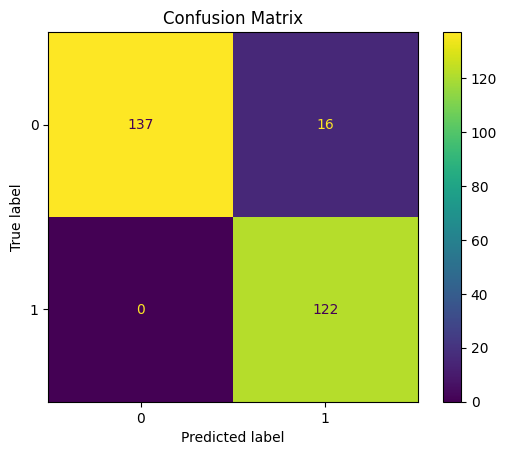

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Train_test_split is splitting the data %80 to %20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 , stratify=y)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# Initializing and training the model
dt = DecisionTreeClassifier(max_depth=3, criterion='entropy', min_samples_split=10, random_state=42)
dt.fit(X_train, y_train)

# Prediction
y_pred = dt.predict(X_test)

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Confusion Matrix')
plt.show()

4. Tree Visualization

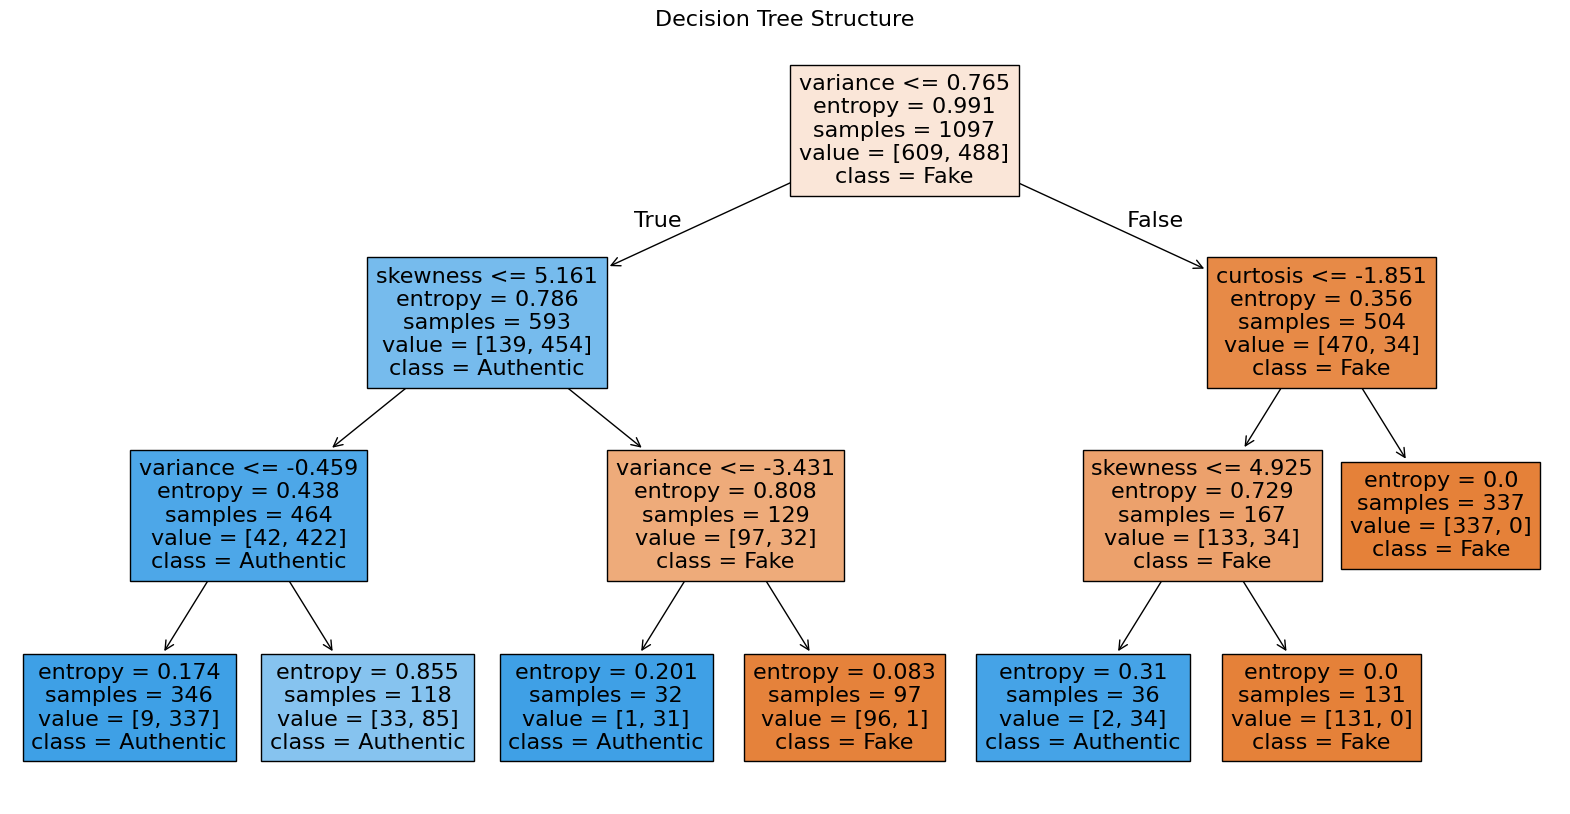

In [3]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=X.columns, class_names=['Fake', 'Authentic'], filled=True)
plt.title('Decision Tree Structure', fontsize=16)
plt.show()

Analysis: A smaller max_depth enhances interpretability by simplifying the tree.

5. Feature Importance

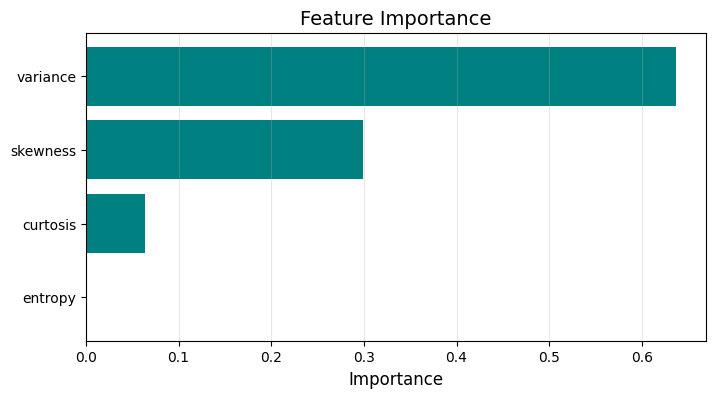

In [4]:
plt.figure(figsize=(8, 4))
plt.barh(X.columns, dt.feature_importances_, color='teal')
plt.title('Feature Importance', fontsize=14)
plt.xlabel('Importance', fontsize=12)
plt.gca().invert_yaxis()  # Most important at top
plt.grid(axis='x', alpha=0.3)
plt.show()

6. Conclusion
The decision tree achieved high accuracy (~98%), making it suitable for this dataset. Its interpretability and performance justify its use.
